## Setup

In [22]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

eps = 1e-9

## Load & parse data

In [23]:
train_raw = pd.read_csv("Data/Updated_Training.csv")
test_raw  = pd.read_csv("Data/Updated 2025-2026.csv")
train_raw.head()

,RecordID,Season,Team,Conference,Overall Seed,Bid Type,NET Rank,PrevNET,AvgOppNETRank,AvgOppNET,WL,Conf.Record,Non-ConferenceRecord,RoadWL,NETSOS,NETNonConfSOS,Quadrant1,Quadrant2,Quadrant3,Quadrant4,ORtg,DRtg,AdjT,Luck,PTS,FG%,3P%,FT%,OR,DR,REB,AST,STL,BLK,TO,PF
0,2020-21-UCDavis,2020-21,UC Davis,Big West,NaN,NaN,223.0,224.0,240.0,211.0,8-Sep,5-Jul,3-Feb,3-Apr,264.0,287.0,0-0,0-3,2-Jan,3-Aug,98.0,102.3,69.2,0.087,72.5,44.7,33.2,77.9,9.2,22.2,31.5,10.9,7.4,2.8,14.6,19.6
1,2020-21-MichiganSt.,2020-21,Michigan St.,Big Ten,43.0,AL,70.0,70.0,20.0,75.0,15-12,12-Sep,Jun-00,8-Mar,9.0,238.0,10-May,2-Apr,Feb-00,Apr-00,107.1,94.2,68.3,0.090,69.4,42.6,32.1,72.7,10.9,26.6,37.4,15.9,4.5,4.7,13.0,19.8
2,2020-21-ULM,2020-21,ULM,Sun Belt,NaN,NaN,292.0,292.0,244.0,214.0,19-Jul,14-May,5-Feb,10-Feb,313.0,263.0,0-0,0-1,7-Feb,11-May,93.2,105.4,67.1,-0.040,64.2,41.6,34.0,70.3,7.9,22.5,30.4,13.7,7.4,2.8,13.0,16.7
3,2020-21-CentralConn.St.,2020-21,Central Conn. St.,NEC,NaN,NaN,301.0,301.0,200.0,195.0,16-May,13-May,0-3,9-Feb,242.0,54.0,0-1,0-2,6-Feb,7-Mar,92.5,112.0,70.3,0.003,68.5,42.4,32.4,70.2,8.7,23.0,31.6,12.9,6.9,2.6,14.2,17.1
4,2020-21-Colgate,2020-21,Colgate,Patriot,57.0,AQ,9.0,9.0,154.0,169.0,14-1,14-1,0-0,Jun-00,257.0,NaN,0-0,Feb-00,1-Jun,Jun-00,110.3,101.0,72.2,0.048,85.2,49.3,40.3,72.3,9.8,30.1,39.9,17.6,7.1,3.4,10.8,16.2


In [24]:
test_raw.head()

,RecordID,Season,Team,Conference,Bid Type,NET Rank,PrevNET,AvgOppNETRank,AvgOppNET,WL,Conf.Record,Non-ConferenceRecord,RoadWL,NETSOS,NETNonConfSOS,Quadrant1,Quadrant2,Quadrant3,Quadrant4,ORtg,DRtg,AdjT,Luck,PTS,FG%,3P%,FT%,OR,DR,REB,AST,STL,BLK,TO,PF
0,2025-26-Coastal Carolina,2025-26,Coastal Carolina,Sun Belt,NaN,229,218,260,221,18-13,11-8,7-5,10-7,322,306,0-1,2-1,4-4,12-7,102.1,109.0,66.8,0.132,73.3,41.2,33.9,72.9,10.6,29.5,40.1,10.4,4.4,3.3,10.8,18.4
1,2025-26-Washington St.,2025-26,Washington St.,WCC,NaN,141,143,91,135,11-20,7-12,4-8,1-11,95,151,0-4,0-10,5-3,6-3,114.3,112.0,67.8,-0.094,76.1,46.7,36.9,74.2,9.8,24.5,34.3,13.9,5.6,2.9,13.0,17.8
2,2025-26-Nicholls,2025-26,Nicholls,Southland,NaN,248,249,194,196,12-18,12-10,0-8,7-12,167,46,0-2,1-6,2-4,9-6,106.1,112.3,68.2,0.044,72.4,43.6,33.4,66.7,10.5,20.6,31.1,13.2,9.0,2.7,11.9,17.8
3,2025-26-FGCU,2025-26,FGCU,ASUN,NaN,246,247,270,225,14-18,10-11,4-7,3-11,273,132,0-3,0-0,2-6,12-9,105.9,112.5,67.5,-0.029,77.4,45.4,32.4,71.9,11.9,25.0,36.9,14.7,7.7,3.6,11.0,18.6
4,2025-26-Eastern Mich.,2025-26,Eastern Mich.,MAC,NaN,240,240,177,189,9-21,4-14,5-7,3-14,146,140,1-2,0-5,1-8,7-6,102.2,108.6,66.5,-0.096,70.7,44.6,32.2,72.8,10.0,25.5,35.5,12.6,5.9,4.2,11.9,18.3


In [25]:
RECORD_COLS = ["WL","Conf.Record","Non-ConferenceRecord","RoadWL",
               "Quadrant1","Quadrant2","Quadrant3","Quadrant4"]
MONTH_MAP   = {"Jan":"1","Feb":"2","Mar":"3","Apr":"4","May":"5","Jun":"6",
               "Jul":"7","Aug":"8","Sep":"9","Oct":"10","Nov":"11","Dec":"12"}

def parse_records(df):
    df = df.copy()
    for col in RECORD_COLS:
        if col not in df.columns: continue
        s = df[col].astype(str)
        for m, n in MONTH_MAP.items(): s = s.str.replace(m, n, regex=False)
        sp = s.str.split("-", expand=True)
        if sp.shape[1] >= 2:
            df[f"{col}_W"] = pd.to_numeric(sp[0], errors="coerce")
            df[f"{col}_L"] = pd.to_numeric(sp[1], errors="coerce")
        df.drop(columns=[col], inplace=True)
    return df

train = parse_records(train_raw)
test  = parse_records(test_raw)
train.head()

,RecordID,Season,Team,Conference,Overall Seed,Bid Type,NET Rank,PrevNET,AvgOppNETRank,AvgOppNET,NETSOS,NETNonConfSOS,ORtg,DRtg,AdjT,Luck,PTS,FG%,3P%,FT%,OR,DR,REB,AST,STL,BLK,TO,PF,WL_W,WL_L,Conf.Record_W,Conf.Record_L,Non-ConferenceRecord_W,Non-ConferenceRecord_L,RoadWL_W,RoadWL_L,Quadrant1_W,Quadrant1_L,Quadrant2_W,Quadrant2_L,Quadrant3_W,Quadrant3_L,Quadrant4_W,Quadrant4_L
0,2020-21-UCDavis,2020-21,UC Davis,Big West,NaN,NaN,223.0,224.0,240.0,211.0,264.0,287.0,98.0,102.3,69.2,0.087,72.5,44.7,33.2,77.9,9.2,22.2,31.5,10.9,7.4,2.8,14.6,19.6,8,9,5,7,3,2,3,4,0,0,0,3,2,1,3,8
1,2020-21-MichiganSt.,2020-21,Michigan St.,Big Ten,43.0,AL,70.0,70.0,20.0,75.0,9.0,238.0,107.1,94.2,68.3,0.090,69.4,42.6,32.1,72.7,10.9,26.6,37.4,15.9,4.5,4.7,13.0,19.8,15,12,12,9,6,0,8,3,10,5,2,4,2,0,4,0
2,2020-21-ULM,2020-21,ULM,Sun Belt,NaN,NaN,292.0,292.0,244.0,214.0,313.0,263.0,93.2,105.4,67.1,-0.040,64.2,41.6,34.0,70.3,7.9,22.5,30.4,13.7,7.4,2.8,13.0,16.7,19,7,14,5,5,2,10,2,0,0,0,1,7,2,11,5
3,2020-21-CentralConn.St.,2020-21,Central Conn. St.,NEC,NaN,NaN,301.0,301.0,200.0,195.0,242.0,54.0,92.5,112.0,70.3,0.003,68.5,42.4,32.4,70.2,8.7,23.0,31.6,12.9,6.9,2.6,14.2,17.1,16,5,13,5,0,3,9,2,0,1,0,2,6,2,7,3
4,2020-21-Colgate,2020-21,Colgate,Patriot,57.0,AQ,9.0,9.0,154.0,169.0,257.0,NaN,110.3,101.0,72.2,0.048,85.2,49.3,40.3,72.3,9.8,30.1,39.9,17.6,7.1,3.4,10.8,16.2,14,1,14,1,0,0,6,0,0,0,2,0,1,6,6,0


## Feature engineering

In [26]:
def engineer(df):
    df = df.copy()

    # Win rates
    df["WinPct"]        = df["WL_W"]         / (df["WL_W"]          + df["WL_L"]          + eps)
    df["ConfWinPct"]    = df["Conf.Record_W"] / (df["Conf.Record_W"] + df["Conf.Record_L"] + eps)
    df["RoadWinPct"]    = df["RoadWL_W"]      / (df["RoadWL_W"]      + df["RoadWL_L"]      + eps)
    df["Q1_WinRate"]    = df["Quadrant1_W"]   / (df["Quadrant1_W"]   + df["Quadrant1_L"]   + eps)
    df["NonConfWinPct"] = df["Non-ConferenceRecord_W"] / (
                          df["Non-ConferenceRecord_W"] + df["Non-ConferenceRecord_L"] + eps)

    # Resume quality
    df["ResumeScore"] = df["Quadrant1_W"]*3 + df["Quadrant2_W"]*2 - df["Quadrant3_L"]*2 - df["Quadrant4_L"]*3
    df["Q1_Net"]      = df["Quadrant1_W"] - df["Quadrant1_L"]
    df["Bad_Losses"]  = df["Quadrant3_L"] + df["Quadrant4_L"]
    df["Q12_W"]       = df["Quadrant1_W"] + df["Quadrant2_W"]   # quality wins
    df["Q34_L"]       = df["Quadrant3_L"] + df["Quadrant4_L"]   # bad losses

    # Efficiency
    df["EffMargin"]     = df["ORtg"] - df["DRtg"]
    df["KenPom_Gap"]    = df["EffMargin"] - (50 - df["NET Rank"]) * 0.3
    df["ORtg_x_WinPct"] = df["ORtg"] * df["WinPct"]

    # NET rank signals
    df["log_NET"]   = np.log1p(df["NET Rank"])
    df["NET_Delta"] = df["PrevNET"] - df["NET Rank"]
    df["NET_sq"]    = df["NET Rank"] ** 2

    # Season-relative rank
    season_n        = df.groupby("Season")["NET Rank"].transform("count")
    df["NET_SRank"] = df.groupby("Season")["NET Rank"].rank(ascending=True)
    df["NET_Pct"]   = df["NET_SRank"] / season_n

    return df

train = engineer(train)
test  = engineer(test)

In [27]:
print(train.columns)
print(test.columns)

Index(['RecordID', 'Season', 'Team', 'Conference', 'Overall Seed', 'Bid Type',
       'NET Rank', 'PrevNET', 'AvgOppNETRank', 'AvgOppNET', 'NETSOS',
       'NETNonConfSOS', 'ORtg', 'DRtg', 'AdjT', 'Luck', 'PTS', 'FG%', '3P%',
       'FT%', 'OR', 'DR', 'REB', 'AST', 'STL', 'BLK', 'TO', 'PF', 'WL_W',
       'WL_L', 'Conf.Record_W', 'Conf.Record_L', 'Non-ConferenceRecord_W',
       'Non-ConferenceRecord_L', 'RoadWL_W', 'RoadWL_L', 'Quadrant1_W',
       'Quadrant1_L', 'Quadrant2_W', 'Quadrant2_L', 'Quadrant3_W',
       'Quadrant3_L', 'Quadrant4_W', 'Quadrant4_L', 'WinPct', 'ConfWinPct',
       'RoadWinPct', 'Q1_WinRate', 'NonConfWinPct', 'ResumeScore', 'Q1_Net',
       'Bad_Losses', 'Q12_W', 'Q34_L', 'EffMargin', 'KenPom_Gap',
       'ORtg_x_WinPct', 'log_NET', 'NET_Delta', 'NET_sq', 'NET_SRank',
       'NET_Pct'],
      dtype='str')
Index(['RecordID', 'Season', 'Team', 'Conference', 'Bid Type', 'NET Rank',
       'PrevNET', 'AvgOppNETRank', 'AvgOppNET', 'NETSOS', 'NETNonConfSOS',
       '

## Feature selection via SHAP (LossFunctionChange)

In [28]:
CANDIDATES = [col for col in train.columns if col not in ["RecordID", "Overall Seed", "Bid Type"]]
CANDIDATES

['Season',
 'Team',
 'Conference',
 'NET Rank',
 'PrevNET',
 'AvgOppNETRank',
 'AvgOppNET',
 'NETSOS',
 'NETNonConfSOS',
 'ORtg',
 'DRtg',
 'AdjT',
 'Luck',
 'PTS',
 'FG%',
 '3P%',
 'FT%',
 'OR',
 'DR',
 'REB',
 'AST',
 'STL',
 'BLK',
 'TO',
 'PF',
 'WL_W',
 'WL_L',
 'Conf.Record_W',
 'Conf.Record_L',
 'Non-ConferenceRecord_W',
 'Non-ConferenceRecord_L',
 'RoadWL_W',
 'RoadWL_L',
 'Quadrant1_W',
 'Quadrant1_L',
 'Quadrant2_W',
 'Quadrant2_L',
 'Quadrant3_W',
 'Quadrant3_L',
 'Quadrant4_W',
 'Quadrant4_L',
 'WinPct',
 'ConfWinPct',
 'RoadWinPct',
 'Q1_WinRate',
 'NonConfWinPct',
 'ResumeScore',
 'Q1_Net',
 'Bad_Losses',
 'Q12_W',
 'Q34_L',
 'EffMargin',
 'KenPom_Gap',
 'ORtg_x_WinPct',
 'log_NET',
 'NET_Delta',
 'NET_sq',
 'NET_SRank',
 'NET_Pct']

In [29]:
print(f"Total Observations in Train: {len(train['RecordID'].unique())}")
train.dropna(subset=['Overall Seed'], inplace=True)
print(f"Competing Teams in Train: {len(train['RecordID'].unique())}")

Total Observations in Train: 1353
Competing Teams in Train: 249


In [30]:
X_train = train[CANDIDATES]
y_train = train["Overall Seed"]

print(X_train.shape)
print(y_train.shape)

(249, 59)
(249,)


In [33]:
# detect categorical columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# make categorical columns safe for CatBoost
for c in cat_cols:
    X_train[c] = X_train[c].fillna("Missing").astype(str)

print(f"Categorical Columns: {cat_cols}")

Categorical Columns: ['Season', 'Team', 'Conference']


In [34]:
# Fit a CatBoost model to rank the features by importance
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_cols
)

selector = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

selector.fit(train_pool)

CatBoostRegressor(depth=6, iterations=500, l2_leaf_reg=3, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0)

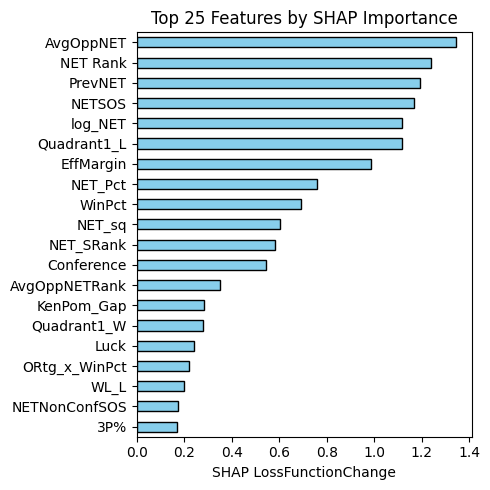

In [36]:
# Get SHAP feature importances (LossFunctionChange)
shap_imp = selector.get_feature_importance(data=Pool(data=X_train, label=y_train, cat_features=cat_cols), type="LossFunctionChange")
shap_series = pd.Series(shap_imp, index=CANDIDATES).sort_values(ascending=False)

# Plot the top 25 features by SHAP importance
top_features = shap_series.head(20)

plt.figure(figsize=(5, 5))
top_features.plot(kind='barh', color='skyblue', edgecolor='black')
plt.xlabel('SHAP LossFunctionChange')
plt.title('Top 25 Features by SHAP Importance')
plt.gca().invert_yaxis()  # Reverse the order to show highest importance at the top
plt.tight_layout()
plt.show()

In [42]:
# Final top 20 features based on SHAP importance
FEATURES = shap_series.head(20).index.tolist()

# Split numeric / categorical
num_cols = train[FEATURES].select_dtypes(include=["number"]).columns.tolist()
cat_cols = train[FEATURES].select_dtypes(include=["object", "category"]).columns.tolist()

# Train set
X = train[FEATURES].copy()
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Missing").astype(str)
y = train["Overall Seed"]

# Test set
X_test = test[FEATURES].copy()
X_test[num_cols] = X_test[num_cols].fillna(X[num_cols].median())
X_test[cat_cols] = X_test[cat_cols].fillna("Missing").astype(str)

n_test_all = len(test)

## Cross-validation — KFold + GroupKFold

Two strategies :
- **KFold** : standard 5-fold, good baseline
- **GroupKFold by Season** : holds out entire seasons, simulates predicting a brand-new season (more realistic for Kaggle)

Final OOF is the average of both.

In [43]:
mono = [0] * len(FEATURES)

positive_constraints = [
    "NET Rank",
    "log_NET",
    "NET_sq",
    "PrevNET",
    "AvgOppNETRank",
    "AvgOppNET",
    "NETSOS",
    "NETNonConfSOS",
    "Bad_Losses",
    "NET_SRank",
    "NET_Pct"
]

negative_constraints = [
    "ResumeScore",
    "EffMargin",
    "KenPom_Gap"
]

for feat in positive_constraints:
    if feat in FEATURES:
        mono[FEATURES.index(feat)] = 1

for feat in negative_constraints:
    if feat in FEATURES:
        mono[FEATURES.index(feat)] = -1

CB_PARAMS = dict(
    iterations           = 800,
    learning_rate        = 0.04,
    depth                = 6,
    l2_leaf_reg          = 4,
    min_data_in_leaf     = 3,
    monotone_constraints = mono,
    random_seed          = 42,
    verbose              = 0,
)

seasons = train["Season"].values

In [46]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

def run_cv(splitter, label):
    oof, models, tr_rmses, vl_rmses = np.zeros(len(X)), [], [], []
    is_group = isinstance(splitter, GroupKFold)

    split_iter = splitter.split(X, y, seasons) if is_group else splitter.split(X)

    for fold, (tr, vl) in enumerate(split_iter, 1):
        model = CatBoostRegressor(**CB_PARAMS)

        train_pool = Pool(
            X.iloc[tr],
            y.iloc[tr],
            cat_features=cat_cols
        )
        valid_pool = Pool(
            X.iloc[vl],
            y.iloc[vl],
            cat_features=cat_cols
        )

        model.fit(
            train_pool,
            eval_set=valid_pool,
            early_stopping_rounds=60
        )

        oof[vl] = model.predict(valid_pool)

        tr_rmse = np.sqrt(mean_squared_error(y.iloc[tr], model.predict(train_pool)))
        vl_rmse = np.sqrt(mean_squared_error(y.iloc[vl], oof[vl]))

        models.append(model)
        tr_rmses.append(tr_rmse)
        vl_rmses.append(vl_rmse)

        print(f"  [{label}] fold {fold}  train={tr_rmse:.3f}  val={vl_rmse:.3f}  iter={model.best_iteration_}")

    return oof, models, tr_rmses, vl_rmses


print("KFold -5 ")
kf_oof,  kf_models,  kf_tr,  kf_vl  = run_cv(KFold(n_splits=5, shuffle=True, random_state=42), "KF")

print("GroupKFold by Season")
gkf_oof, gkf_models, gkf_tr, gkf_vl = run_cv(GroupKFold(n_splits=5), "GKF")


KFold -5 
  [KF] fold 1  train=1.859  val=5.363  iter=555
  [KF] fold 2  train=2.233  val=4.516  iter=502
  [KF] fold 3  train=1.404  val=4.047  iter=799
  [KF] fold 4  train=2.209  val=5.399  iter=402
  [KF] fold 5  train=2.420  val=6.127  iter=389
GroupKFold by Season
  [GKF] fold 1  train=3.995  val=5.850  iter=141
  [GKF] fold 2  train=3.125  val=4.938  iter=268
  [GKF] fold 3  train=1.947  val=6.251  iter=536
  [GKF] fold 4  train=2.578  val=5.232  iter=395
  [GKF] fold 5  train=2.593  val=4.372  iter=415


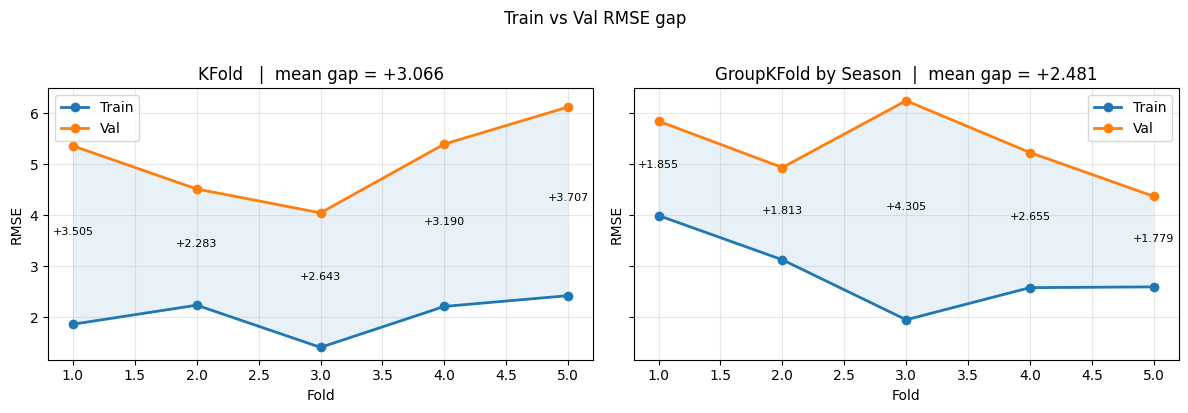

In [47]:
folds = list(range(1, 6))
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, tr, vl, title in [
    (axes[0], kf_tr,  kf_vl,  "KFold "),
    (axes[1], gkf_tr, gkf_vl, "GroupKFold by Season"),
]:
    gaps = np.array(vl) - np.array(tr)
    ax.plot(folds, tr, marker="o", label="Train", linewidth=2)
    ax.plot(folds, vl, marker="o", label="Val",   linewidth=2)
    ax.fill_between(folds, tr, vl, alpha=0.1)
    for f, g, t, v in zip(folds, gaps, tr, vl):
        ax.annotate(f"{g:+.3f}", xy=(f, (t + v) / 2), ha="center", fontsize=8)
    ax.set(title=f"{title}  |  mean gap = {gaps.mean():+.3f}", xlabel="Fold", ylabel="RMSE")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Train vs Val RMSE gap", y=1.02)
plt.tight_layout()
plt.show()

## Final predictions & submission

In [ ]:
# categorical columns in X / X_test
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# final model on all data
final_cb = CatBoostRegressor(**CB_PARAMS)
final_cb.fit(Pool(X, y, cat_features=cat_cols))

all_fold_models = kf_models + gkf_models

# build test pool once
test_pool = Pool(X_test, cat_features=cat_cols)

# average predictions across all fold models + final model
raw_preds = np.mean(
    [m.predict(test_pool) for m in all_fold_models + [final_cb]],
    axis=0
)

# round and clip
seeds = np.clip(np.round(raw_preds).astype(int), 1, 68)

# already classified teams
classified = pd.read_csv("Results/Classified.csv")[["RecordID", "Overall Seed"]]

# fill predicted seeds only where Overall Seed is missing
test = test.merge(classified, on="RecordID", how="left")
test["Overall Seed"] = test["Overall Seed"].fillna(pd.Series(seeds, index=test.index)).astype(int)

test.to_csv("Results/FFinal_Submission.csv", index=False)

## Submission preview

In [50]:
submission

,RecordID,Overall Seed
0,2020-21-Baylor,3
1,2020-21-Arkansas,13
2,2020-21-Purdue,16
3,2020-21-OklahomaSt.,14
4,2020-21-SouthernCalifornia,18
5,2020-21-TexasTech,21
6,2020-21-Wisconsin,29
7,2020-21-Syracuse,37
8,2020-21-UCLA,34
9,2020-21-Winthrop,47
